# Détection de Transactions Atypiques dans les Données de Mobile Money
### Projet Intégrateur — Certificat en Sciences des Données & Mathématiques pour l'IA (FRST — FDS / UEH)

**Étudiants :** JEAN-LOUIS Berckson Johnsly · MORISSET Nherlyse · SERVILUS Bendy
**Jeu de données :** PaySim (Kaggle) — simulateur de transactions de mobile money, utilisé comme proxy réaliste des flux MonCash / NatCash
**Cible :** `isFraud` (transaction frauduleuse ou légitime)

---

## Table des matières
1. Chargement et qualité des données
2. Analyse exploratoire multivariée
3. Feature engineering
4. Séparation Train / Test
5. Pipeline de prétraitement
6. Modélisation supervisée (Logistic Regression, Decision Tree, Random Forest)
7. Évaluation approfondie (Courbes ROC / Précision-Rappel — indispensables sur données déséquilibrées)
8. Importance des variables
9. Analyse en Composantes Principales (ACP)
10. Détection d'anomalies non supervisée (Isolation Forest, DBSCAN)
11. Synthèse, limites et considérations éthiques

---
**Note méthodologique :** le résumé de cadrage du projet (avril 2026) prévoyait une approche uniquement non supervisée sur données synthétiques. Le pivot vers PaySim — un jeu de données public, réaliste et **labellisé** — a permis d'enrichir le travail avec une approche supervisée plus robuste, tout en conservant les méthodes non supervisées annoncées (ACP, Isolation Forest, DBSCAN) à des fins de comparaison et de validation croisée des approches. Cette justification est développée en section 11.

In [2]:
# ==============================================================================
# IMPORTING ALL NECESSARY LIBRARIES FOR DATA SCIENCE PIPELINE
# ==============================================================================

# Librairies de base pour la manipulation des donnees
import pandas as pd
import numpy as np

# Librairies de visualisation pour l'analyse exploratoire (EDA)
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import plot, iplot, init_notebook_mode

# Initialisation du mode notebook pour les graphiques interactifs Plotly
init_notebook_mode(connected=True)

# Commande magique pour afficher les graphiques Matplotlib directement sous la cellule
%matplotlib inline

# Outils de pretraitement des donnees (Preprocessing)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

# Algorithmes de Machine Learning pour la classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, IsolationForest
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC

# Reduction de dimension et clustering non supervise (ACP, DBSCAN)
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

# Outils pour la creation de pipelines et la recherche d'hyperparametres
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score

# Metriques d'evaluation de la performance des modeles
from sklearn import metrics
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    silhouette_score
)

# Gestion des alertes pour garder la console propre
import warnings
warnings.filterwarnings("ignore")

# Style graphique commun pour l'ensemble du notebook
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

print("Tous les packages ont ete importes avec succes !")

Tous les packages ont ete importes avec succes !


## 1. Chargement et qualité des données

In [3]:
# ==============================================================================
# Chargement du dataset PaySim et verification de la presence de valeurs manquantes
# ==============================================================================

# Configuration de pandas pour afficher toutes les colonnes sans coupure
pd.set_option('display.max_columns', None)

# Definition du chemin d'acces au fichier csv de Kaggle PaySim
dataset_path = "datasets/PS_20174392719_1491204439457_log.csv"

# Chargement du dataset complet avec Pandas
print("Chargement des donnees en cours...")
df_paysim = pd.read_csv(dataset_path)
print("Chargement termine avec succes !\n")

# Affichage des dimensions reelles du dataset
print("--- Dimensions du Dataset ---")
print(f"Nombre de lignes : {df_paysim.shape[0]:,}")
print(f"Nombre de colonnes : {df_paysim.shape[1]}\n")

# Verification des types de donnees et de la memoire utilisee
print("--- Informations generales sur les colonnes ---")
print(df_paysim.info())

# Verification stricte de la presence de valeurs manquantes (NaN)
print("\n--- Verification des valeurs manquantes ---")
missing_counts = df_paysim.isnull().sum()
if missing_counts.sum() == 0:
    print("Parfait ! Aucune valeur manquante n'a ete detectee dans ce dataset.")
else:
    print("Attention, colonnes avec valeurs manquantes :")
    print(missing_counts[missing_counts > 0])

# Apercu des 5 premieres lignes du dataset
print("\n--- Apercu des 5 premieres lignes ---")
df_paysim.head()

Chargement des donnees en cours...
Chargement termine avec succes !

--- Dimensions du Dataset ---
Nombre de lignes : 6,362,620
Nombre de colonnes : 11

--- Informations generales sur les colonnes ---
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB
None

--- Verification des valeurs manquantes ---
Parfait ! Aucune valeur manquante n'a ete detectee dans ce dataset.

--- Apercu des 5 premieres lignes ---


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


--- Distribution de la variable cible isFraud ---
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Proportion de fraude : 0.1291%
Proportion legitime  : 99.8709%

Ratio de desequilibre : 1 fraude pour environ 773 transactions legitimes


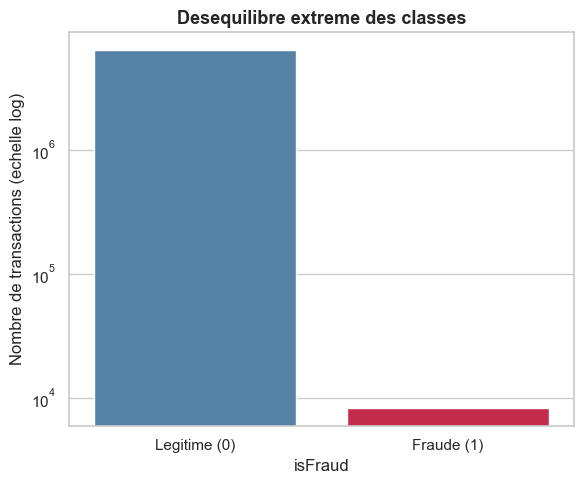

In [4]:
# ==============================================================================
# DESEQUILIBRE DES CLASSES : POINT CRITIQUE A DOCUMENTER DANS LE RAPPORT (section 4.2 / 4.7)
# ==============================================================================
fraud_counts = df_paysim['isFraud'].value_counts()
fraud_pct = df_paysim['isFraud'].value_counts(normalize=True) * 100

print("--- Distribution de la variable cible isFraud ---")
print(fraud_counts)
print(f"\nProportion de fraude : {fraud_pct[1]:.4f}%")
print(f"Proportion legitime  : {fraud_pct[0]:.4f}%")
print(f"\nRatio de desequilibre : 1 fraude pour environ {int(fraud_counts[0]/fraud_counts[1])} transactions legitimes")

plt.figure(figsize=(6, 5))
sns.barplot(x=fraud_counts.index.astype(str), y=fraud_counts.values, palette=['steelblue', 'crimson'])
plt.yscale('log')
plt.xticks([0, 1], ['Legitime (0)', 'Fraude (1)'])
plt.ylabel("Nombre de transactions (echelle log)")
plt.title("Desequilibre extreme des classes", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Analyse exploratoire multivariée

--- Analyse Multivariee : Matrice de Correlation ---


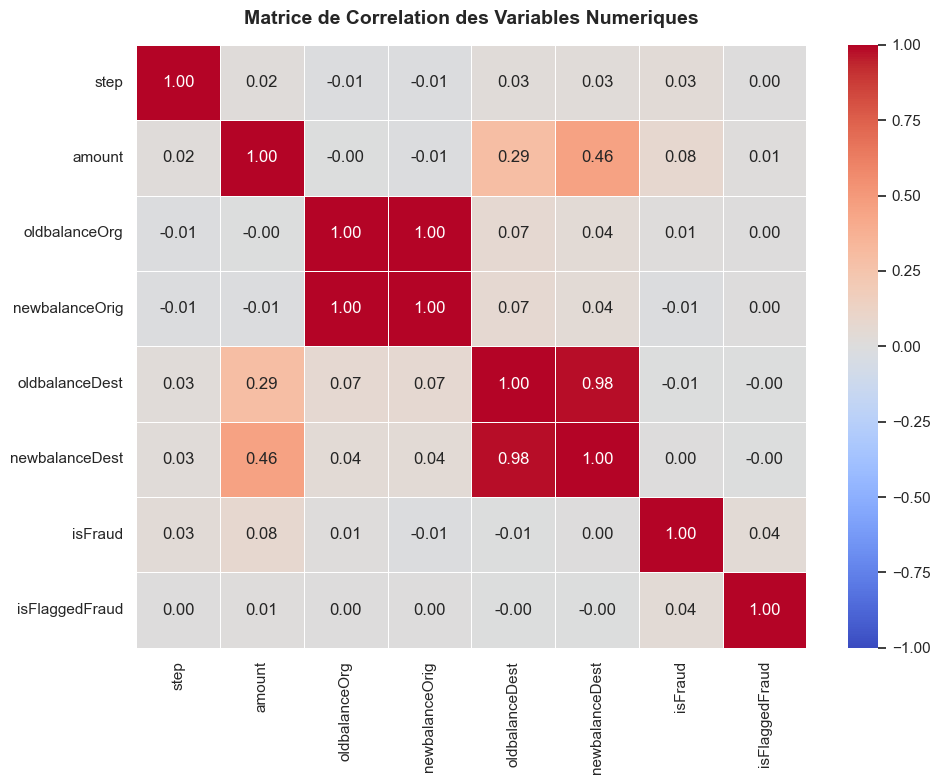

In [5]:
# ==============================================================================
# MATRICE DE CORRELATION DES VARIABLES NUMERIQUES
# ==============================================================================
print("--- Analyse Multivariee : Matrice de Correlation ---")

# Les colonnes a valeurs numeriques
numerical_cols = df_paysim.select_dtypes(include=[np.number]).columns
corr_matrix = df_paysim[numerical_cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Matrice de Correlation des Variables Numeriques", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [6]:
# ==============================================================================
# LECTURE COMMENTEE DE LA MATRICE DE CORRELATION
# ==============================================================================
print("--- Constats a retenir de la matrice de correlation ---\n")

print("1. Multicolinearite forte entre les soldes avant/apres transaction :")
print(f"   corr(oldbalanceOrg, newbalanceOrig)  = {corr_matrix.loc['oldbalanceOrg','newbalanceOrig']:.2f}")
print(f"   corr(oldbalanceDest, newbalanceDest) = {corr_matrix.loc['oldbalanceDest','newbalanceDest']:.2f}")
print("   -> Ces paires sont quasi redondantes : cela justifie le recours a l'ACP")
print("      (section 9) pour synthetiser l'information sans perte majeure de variance.\n")

print("2. Faible correlation lineaire entre isFraud et les variables brutes :")
print(corr_matrix['isFraud'].drop('isFraud').sort_values(key=abs, ascending=False))
print("   -> La fraude n'est pas lineairement separable a partir des variables brutes.")
print("      Cela justifie le feature engineering (errorBalanceOrig/Dest) et l'usage")
print("      de modeles non lineaires (Decision Tree, Random Forest, Isolation Forest).\n")

print("3. isFlaggedFraud est quasi inutile pour detecter la fraude reelle :")
print(f"   corr(isFlaggedFraud, isFraud) = {corr_matrix.loc['isFlaggedFraud','isFraud']:.2f}")
print("   -> Le mecanisme de detection deja integre au systeme (blocage des transferts")
print("      > 200 000) ne capte presque aucune fraude reelle : c'est precisement")
print("      la limite que ce projet cherche a combler (cf. section 11).")

--- Constats a retenir de la matrice de correlation ---

1. Multicolinearite forte entre les soldes avant/apres transaction :
   corr(oldbalanceOrg, newbalanceOrig)  = 1.00
   corr(oldbalanceDest, newbalanceDest) = 0.98
   -> Ces paires sont quasi redondantes : cela justifie le recours a l'ACP
      (section 9) pour synthetiser l'information sans perte majeure de variance.

2. Faible correlation lineaire entre isFraud et les variables brutes :
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceOrig   -0.008148
oldbalanceDest   -0.005885
newbalanceDest    0.000535
Name: isFraud, dtype: float64
   -> La fraude n'est pas lineairement separable a partir des variables brutes.
      Cela justifie le feature engineering (errorBalanceOrig/Dest) et l'usage
      de modeles non lineaires (Decision Tree, Random Forest, Isolation Forest).

3. isFlaggedFraud est quasi inutile pour detecter la fraude reelle :
   corr(isFlaggedFraud, 

In [7]:
# ==============================================================================
# VERIFICATION EMPIRIQUE : LA FRAUDE EST-ELLE VRAIMENT LIMITEE A TRANSFER ET CASH_OUT ?
# ==============================================================================
fraud_by_type = df_paysim.groupby('type')['isFraud'].agg(['sum', 'count'])
fraud_by_type.columns = ['nb_fraudes', 'nb_transactions']
fraud_by_type['taux_fraude_pct'] = (fraud_by_type['nb_fraudes'] / fraud_by_type['nb_transactions']) * 100

print("--- Nombre de fraudes par type de transaction (verifie sur nos donnees) ---")
print(fraud_by_type.sort_values('nb_fraudes', ascending=False))

types_avec_fraude = fraud_by_type[fraud_by_type['nb_fraudes'] > 0].index.tolist()
print(f"\n--> Types de transaction concernes par au moins une fraude : {types_avec_fraude}")
print("--> Ce resultat confirme, sur nos propres donnees, que seules les transactions")
print("    TRANSFER et CASH_OUT contiennent des fraudes -- ce qui est egalement une")
print("    caracteristique documentee du simulateur PaySim (Lopez-Rojas et al., 2016).")
print("    Le filtrage applique dans le graphique suivant est donc justifie empiriquement,")
print("    et pas seulement par la documentation du dataset.")

--- Nombre de fraudes par type de transaction (verifie sur nos donnees) ---
          nb_fraudes  nb_transactions  taux_fraude_pct
type                                                  
CASH_OUT        4116          2237500         0.183955
TRANSFER        4097           532909         0.768799
CASH_IN            0          1399284         0.000000
DEBIT              0            41432         0.000000
PAYMENT            0          2151495         0.000000

--> Types de transaction concernes par au moins une fraude : ['CASH_OUT', 'TRANSFER']
--> Ce resultat confirme, sur nos propres donnees, que seules les transactions
    TRANSFER et CASH_OUT contiennent des fraudes -- ce qui est egalement une
    caracteristique documentee du simulateur PaySim (Lopez-Rojas et al., 2016).
    Le filtrage applique dans le graphique suivant est donc justifie empiriquement,
    et pas seulement par la documentation du dataset.


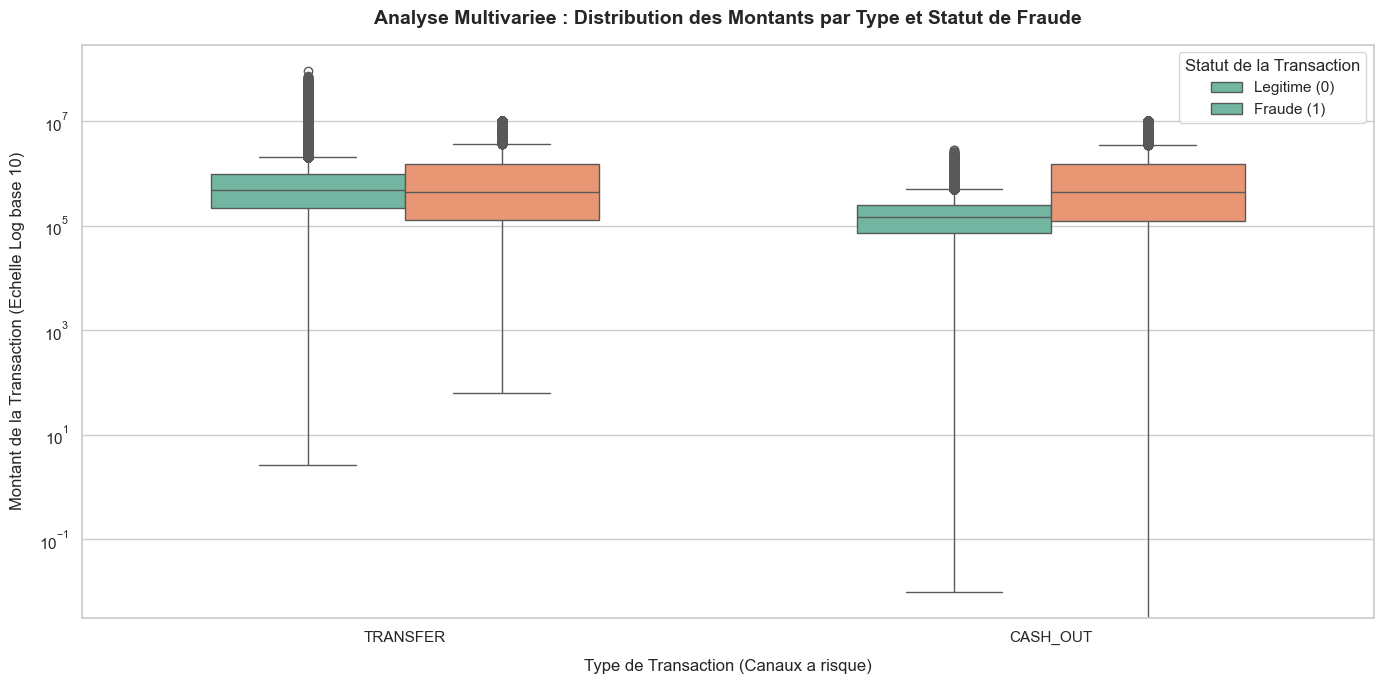

--- Constat ---
Les fraudes se concentrent exclusivement sur TRANSFER et CASH_OUT,
et affichent des montants medians nettement plus eleves que les transactions legitimes.


In [8]:
# ==============================================================================
# GENERATION DU BOXPLOT MULTIVARIE (MONTANT PAR TYPE ET FRAUDE)
# ==============================================================================

# Filtrage : seuls TRANSFER et CASH_OUT contiennent des fraudes dans PaySim
df_filtered = df_paysim[df_paysim['type'].isin(['TRANSFER', 'CASH_OUT'])]

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_filtered,
    x='type',
    y='amount',
    hue='isFraud',
    palette='Set2',
    width=0.6
)

# Echelle logarithmique CRUCIALE : les montants vont de 0.1 a 100 000 000
plt.yscale('log')
plt.title(
    "Analyse Multivariee : Distribution des Montants par Type et Statut de Fraude",
    fontsize=14, fontweight='bold', pad=15
)
plt.xlabel("Type de Transaction (Canaux a risque)", fontsize=12, labelpad=10)
plt.ylabel("Montant de la Transaction (Echelle Log base 10)", fontsize=12, labelpad=10)
plt.legend(title="Statut de la Transaction", labels=["Legitime (0)", "Fraude (1)"])
plt.tight_layout()
plt.show()

print("--- Constat ---")
print("Les fraudes se concentrent exclusivement sur TRANSFER et CASH_OUT,")
print("et affichent des montants medians nettement plus eleves que les transactions legitimes.")

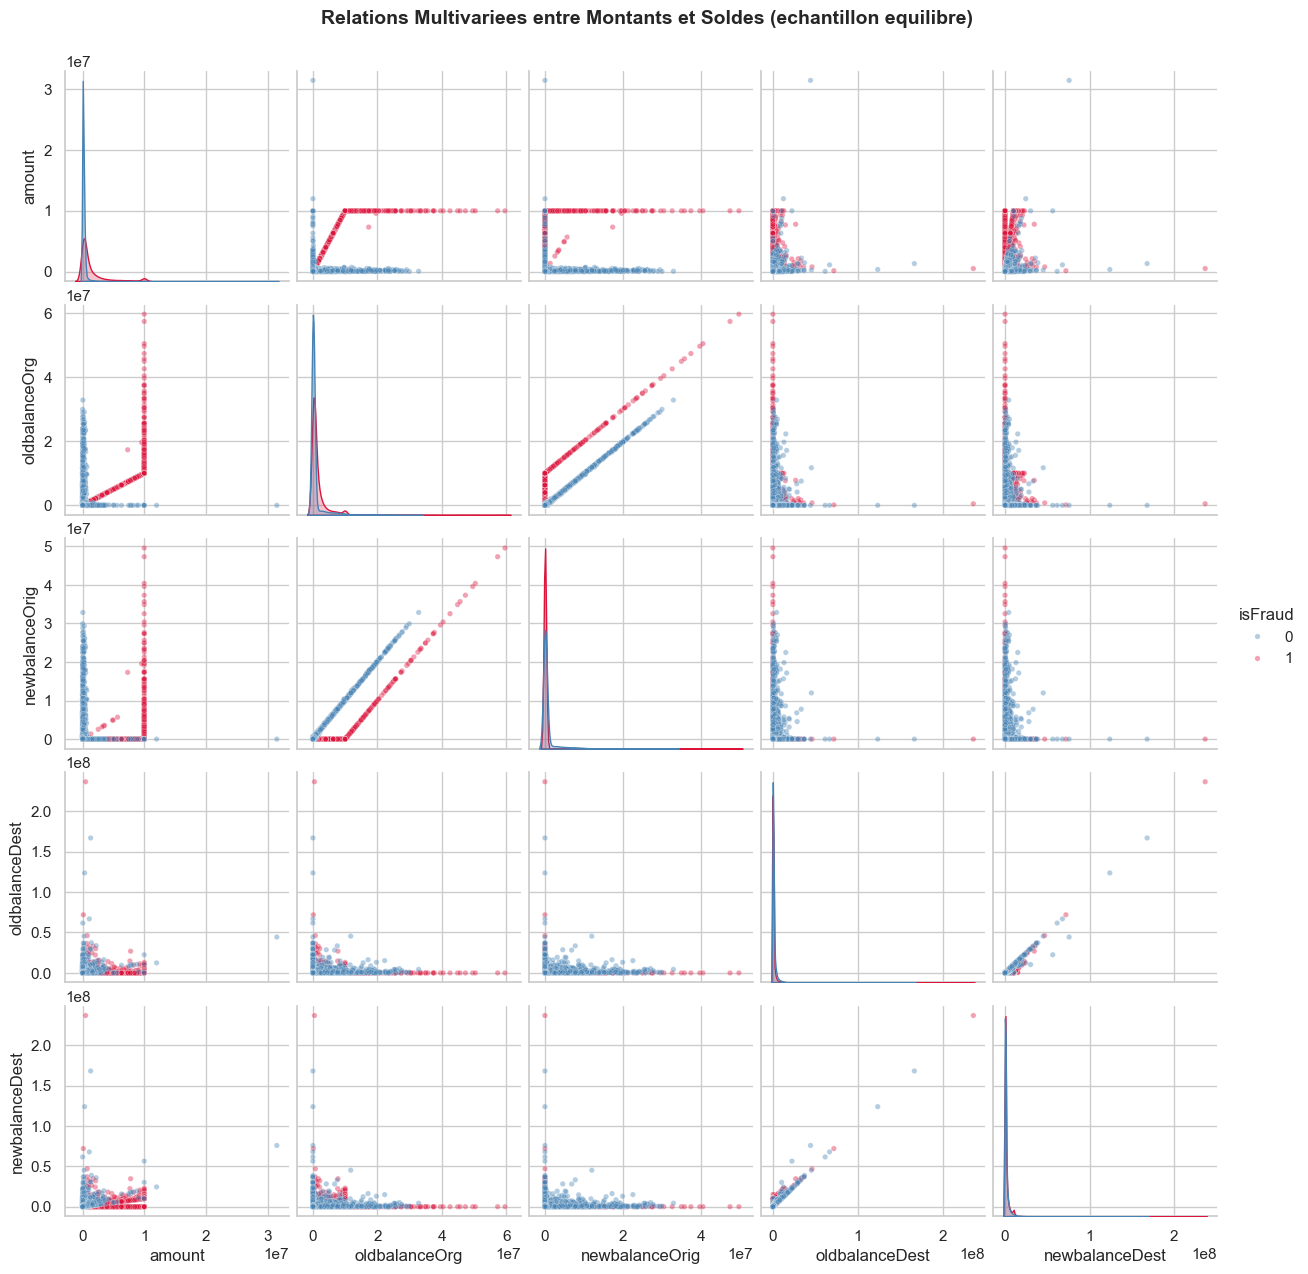

In [9]:
# ==============================================================================
# ANALYSE MULTIVARIEE COMPLEMENTAIRE : PAIRPLOT SUR UN ECHANTILLON EQUILIBRE
# ==============================================================================
# Un pairplot sur plus de 6.4M lignes est illisible et couteux : on construit un
# echantillon equilibre (toutes les fraudes + un nombre egal de legitimes)

fraud_sample = df_paysim[df_paysim['isFraud'] == 1]
legit_sample = df_paysim[df_paysim['isFraud'] == 0].sample(n=len(fraud_sample), random_state=RANDOM_STATE)
df_balanced_sample = pd.concat([fraud_sample, legit_sample])

pairplot_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']

g = sns.pairplot(
    df_balanced_sample[pairplot_cols],
    hue='isFraud',
    palette={0: 'steelblue', 1: 'crimson'},
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde'
)
g.fig.suptitle("Relations Multivariees entre Montants et Soldes (echantillon equilibre)", y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 3. Feature engineering

In [17]:
# ==============================================================================
# FEATURE ENGINEERING (Creation de nouvelles variables et transformation des variables existantes)
# ==============================================================================

# Creation d'un indicateur pour les marchands (Merchants)
# Extraction binaire : 1 si c'est un marchand, 0 sinon
df_paysim['is_merchant'] = df_paysim['nameDest'].str.startswith('M').astype(int)

# Indicateur de grands montants (Surge Indicator)
# Nous marquons les transactions dont le montant est superieur au 75eme percentile complet (~200,000)
# Cela aide le modele a cibler les transferts massifs inhabituels
df_paysim['is_large_amount'] = (df_paysim['amount'] > 200000).astype(int)

# Affichage des nouvelles colonnes creees pour verification
print("--- Nouvelles variables creees avec succes ---")
print(df_paysim[['is_merchant', 'is_large_amount']].head())

print("\nNombre total de colonnes actuel :", df_paysim.shape[1])

--- Nouvelles variables creees avec succes ---
   is_merchant  is_large_amount
0            1                0
1            1                0
2            0                0
3            0                0
4            1                0

Nombre total de colonnes actuel : 15


## 4. Séparation Train / Test

In [18]:
# ==============================================================================
# DATA SPLITTING (TRAIN / TEST SPLIT FOR SECURITY)
# ==============================================================================

# 1. Definition de la variable cible (y) et des variables explicatives (X)
# 'isFraud' est l'etiquette que notre modele doit apprendre a predire
X = df_paysim.drop(columns=['isFraud'])
y = df_paysim['isFraud']

# 2. Division du dataset : 70% pour l'entrainement et 30% pour le test
# Nous fixons le random_state a 42 pour que le decoupage soit reproductible
# L'option stratify=y est tres importante : elle garantit la meme proportion
# de fraudes dans le Train et dans le Test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

# 3. Affichage des dimensions pour verifier le decoupage
print("--- Resultat du decoupage des donnees ---")
print(f"X_train (Entrainement) : {X_train.shape[0]:,} lignes, {X_train.shape[1]} colonnes")
print(f"X_test (Validation)   : {X_test.shape[0]:,} lignes, {X_test.shape[1]} colonnes")

# 4. Verification de la stratification du taux de fraude
print("\n--- Distribution de la cible (Taux de fraude) ---")
print(f"Proportion de fraude dans Train : {(y_train.sum() / len(y_train)) * 100:.4f}%")
print(f"Proportion de fraude dans Test  : {(y_test.sum() / len(y_test)) * 100:.4f}%")

--- Resultat du decoupage des donnees ---
X_train (Entrainement) : 4,453,834 lignes, 14 colonnes
X_test (Validation)   : 1,908,786 lignes, 14 colonnes

--- Distribution de la cible (Taux de fraude) ---
Proportion de fraude dans Train : 0.1291%
Proportion de fraude dans Test  : 0.1291%


## 5. Pipeline de prétraitement

In [19]:
# ==============================================================================
# DEFINING THE PREPROCESSING PIPELINE WITH COLUMNTRANSFORMER
# ==============================================================================

# Definition des groupes de colonnes selon le traitement requis
# Variables numeriques qui ont besoin d'etre normalisees (StandardScaler)
numeric_features = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]

# Variables categoriques qui doivent etre encodees (OneHotEncoder)
categorical_features = ['type']

# Variables binaires ou deja numeriques qu'on laisse telles quelles (Pas de traitement requis)
passthrough_features = ['step', 'is_merchant', 'is_large_amount']

# Construction du ColumnTransformer
# Nous n'avons pas besoin de SimpleImputer ici car nous avons verifie qu'il n'y a pas de NaN
preprocessing_pipeline = ColumnTransformer(
    transformers=[
        # Applique un StandardScaler sur les montants et soldes
        ('num_scaling', Pipeline([
            ('scaler', StandardScaler())
        ]), numeric_features),

        # Applique le OneHotEncoder sur la colonne 'type'
        # handle_unknown='ignore' evite les crashs si une categorie bizarre apparait plus tard
        ('cat_encoding', Pipeline([
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features),

        # Bloc Passthrough : Garde les colonnes deja pretes sans les modifier
        ('pass_features', 'passthrough', passthrough_features)
    ],
    # Les colonnes non mentionnees (comme nameOrig, nameDest, isFlaggedFraud) seront supprimees
    remainder='drop'
)

print("Le ColumnTransformer 'preprocessing_pipeline' a ete defini avec succes !")
print("Il est pret a recevoir les donnees d'entrainement et de test.")

Le ColumnTransformer 'preprocessing_pipeline' a ete defini avec succes !
Il est pret a recevoir les donnees d'entrainement et de test.


In [20]:
# ==============================================================================
# EXECUTION DU PIPELINE DE PREPROCESSING SUR LES DONNEES D'ENTRAINEMENT ET DE TEST
# ==============================================================================

# Entrainement et transformation des donnees d'entrainement (Train Set)
# Le pipeline apprend les moyennes/ecarts-types (StandardScaler) et les categories (OHE)
# uniquement sur le Train Set pour eviter toute fuite de donnees (Data Leakage)
print("Execution du pretraitement sur le Train Set...")
X_train_processed = preprocessing_pipeline.fit_transform(X_train)

# Transformation des donnees de test (Test Set)
# On utilise uniquement .transform() ici, on ne fait SURTOUT PAS de .fit()
# Le Test Set doit etre traite exactement avec les regles apprises sur le Train Set
print("Execution du pretraitement sur le Test Set...")
X_test_processed = preprocessing_pipeline.transform(X_test)

# Recouvrement des noms de colonnes apres transformation
# Le ColumnTransformer retourne un tableau NumPy brut. Pour garder un code propre
# et verifier les colonnes, nous reconstruisons un DataFrame Pandas.
new_columns_names = preprocessing_pipeline.get_feature_names_out()

X_train_final = pd.DataFrame(X_train_processed, columns=new_columns_names, index=X_train.index)
X_test_final = pd.DataFrame(X_test_processed, columns=new_columns_names, index=X_test.index)

# Affichage des resultats et des dimensions
print("\n--- Dimensions apres passage dans le Pipeline ---")
print(f"X_train_final : {X_train_final.shape[0]:,} lignes, {X_train_final.shape[1]} colonnes")
print(f"X_test_final  : {X_test_final.shape[0]:,} lignes, {X_test_final.shape[1]} colonnes\n")

print("--- Liste de toutes les colonnes pretes pour le Machine Learning ---")
print(list(X_train_final.columns))

# Apercu des premieres lignes traitees
X_train_final.head()

Execution du pretraitement sur le Train Set...
Execution du pretraitement sur le Test Set...

--- Dimensions apres passage dans le Pipeline ---
X_train_final : 4,453,834 lignes, 13 colonnes
X_test_final  : 1,908,786 lignes, 13 colonnes

--- Liste de toutes les colonnes pretes pour le Machine Learning ---
['num_scaling__amount', 'num_scaling__oldbalanceOrg', 'num_scaling__newbalanceOrig', 'num_scaling__oldbalanceDest', 'num_scaling__newbalanceDest', 'cat_encoding__type_CASH_IN', 'cat_encoding__type_CASH_OUT', 'cat_encoding__type_DEBIT', 'cat_encoding__type_PAYMENT', 'cat_encoding__type_TRANSFER', 'pass_features__step', 'pass_features__is_merchant', 'pass_features__is_large_amount']


,num_scaling__amount,num_scaling__oldbalanceOrg,num_scaling__newbalanceOrig,num_scaling__oldbalanceDest,num_scaling__newbalanceDest,cat_encoding__type_CASH_IN,cat_encoding__type_CASH_OUT,cat_encoding__type_DEBIT,cat_encoding__type_PAYMENT,cat_encoding__type_TRANSFER,pass_features__step,pass_features__is_merchant,pass_features__is_large_amount
4310249,0.133805,-0.277631,-0.192460,1.042527,0.859216,1.0,0.0,0.0,0.0,0.0,308.0,0.0,1.0
318938,2.005310,-0.139123,-0.292551,-0.324812,-0.052308,0.0,0.0,0.0,0.0,1.0,16.0,0.0,1.0
3375139,1.595985,-0.268089,-0.292551,-0.320385,-0.018948,0.0,0.0,0.0,0.0,1.0,254.0,0.0,1.0
5492781,-0.017525,-0.261134,-0.207299,0.108104,0.019806,1.0,0.0,0.0,0.0,0.0,380.0,0.0,0.0
807263,-0.290836,1.783478,1.756078,0.150109,0.103563,1.0,0.0,0.0,0.0,0.0,40.0,0.0,0.0


## 6. Modélisation supervisée

In [21]:
# ==============================================================================
# ENTRAINEMENT DES MODELES DE MACHINE LEARNING SUPERVISES
# ==============================================================================

# Definition des modeles rapides pour la validation croisee
fast_models_dict = {
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Gaussian Naive Bayes': GaussianNB()
}

print("--- Debut de l'evaluation des modeles rapides (3-Fold CV) ---")

# Dictionnaire pour stocker les scores
cv_results = {}

# Boucle pour evaluer les modeles rapides de maniere robuste
for model_name, model_object in fast_models_dict.items():
    print(f"Evaluation en cours pour : {model_name}...")

    # Nous passons a cv=3 pour reduire encore le temps sur les 4.4 millions de lignes
    cv_scores = cross_val_score(
        model_object,
        X_train_final,
        y_train,
        cv=3,
        scoring='accuracy',
        n_jobs=-1
    )

    cv_results[model_name] = cv_scores.mean()
    print(f"--> {model_name} - Score moyen de precision (Accuracy) : {cv_scores.mean():.6f}\n")


print("--- Entrainement direct du Random Forest (Sans Cross-Validation) ---")
print("Entrainement en cours...")

# Declaration du Random Forest avec 50 arbres et utilisation de tous les coeurs (n_jobs=-1)
rf_model = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1)

# Entrainement direct unique sur la totalite du Train Set final
rf_model.fit(X_train_final, y_train)

# Calcul du score direct sur le Train Set pour comparaison
rf_train_score = rf_model.score(X_train_final, y_train)
print(f"--> Random Forest - Precision directe sur Train Set : {rf_train_score:.6f}\n")

print("--- Toutes les evaluations et entrainements sont termines ! ---")
print("\nATTENTION : l'accuracy est un indicateur trompeur ici (99.87% de legitimes).")
print("Un modele qui predit toujours 'Legitime' obtiendrait deja une accuracy > 99.8%.")
print("Les sections suivantes utilisent donc precision, rappel, F1 et AUC, bien plus pertinents.")

--- Debut de l'evaluation des modeles rapides (3-Fold CV) ---
Evaluation en cours pour : Logistic Regression...
--> Logistic Regression - Score moyen de precision (Accuracy) : 0.999212

Evaluation en cours pour : Decision Tree...
--> Decision Tree - Score moyen de precision (Accuracy) : 0.999659

Evaluation en cours pour : Gaussian Naive Bayes...
--> Gaussian Naive Bayes - Score moyen de precision (Accuracy) : 0.567772

--- Entrainement direct du Random Forest (Sans Cross-Validation) ---
Entrainement en cours...
--> Random Forest - Precision directe sur Train Set : 0.999998

--- Toutes les evaluations et entrainements sont termines ! ---

ATTENTION : l'accuracy est un indicateur trompeur ici (99.87% de legitimes).
Un modele qui predit toujours 'Legitime' obtiendrait deja une accuracy > 99.8%.
Les sections suivantes utilisent donc precision, rappel, F1 et AUC, bien plus pertinents.


Calcul des predictions sur le Test Set pour les deux modeles...

   EVALUATION DU MODELE : DECISION TREE

--- Classification Report (Decision Tree) ---
              precision    recall  f1-score   support

    Legitime       1.00      1.00      1.00   1906322
      Fraude       0.88      0.88      0.88      2464

    accuracy                           1.00   1908786
   macro avg       0.94      0.94      0.94   1908786
weighted avg       1.00      1.00      1.00   1908786

--- Matrice de Confusion (Decision Tree) ---
[[1906023     299]
 [    304    2160]]
-> Fraudes detectees (Vrais Positifs) : 2,160
-> Fraudes ratees (Faux Negatifs)     : 304
-> Bons clients bloques (Faux Positifs) : 299

   EVALUATION DU MODELE : RANDOM FOREST

--- Classification Report (Random Forest) ---
              precision    recall  f1-score   support

    Legitime       1.00      1.00      1.00   1906322
      Fraude       0.98      0.78      0.87      2464

    accuracy                           1.00   190

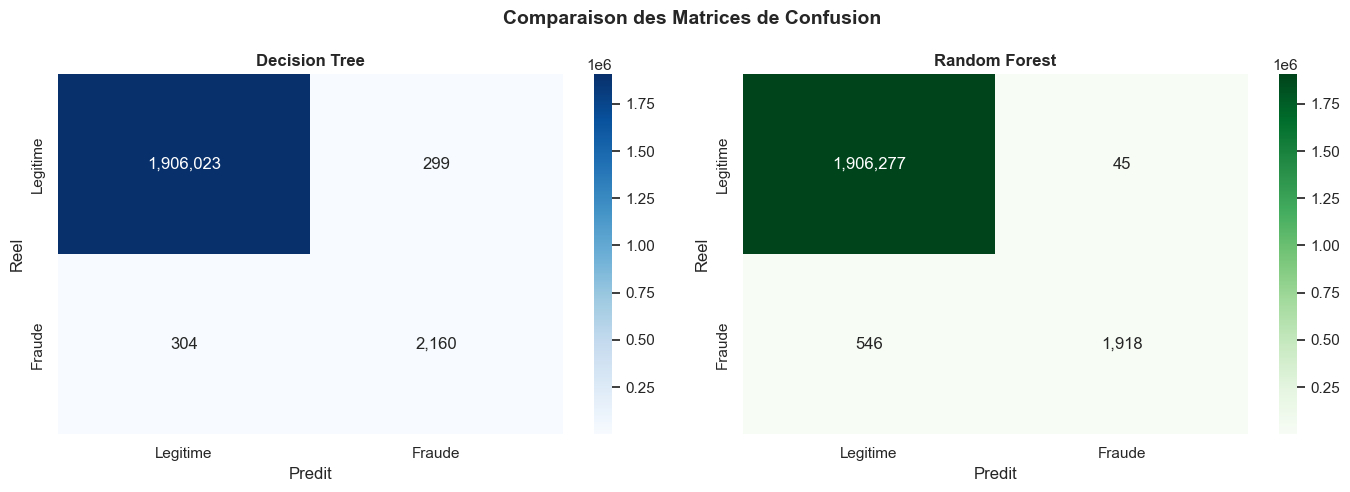

In [22]:
# ==============================================================================
# EVALUATION FINALE DU MODELE RANDOM FOREST ET DECISION TREE SUR LE TEST SET
# ==============================================================================

# Nous devons juste recuperer une Decision Tree entraine proprement pour le test.
dt_model = fast_models_dict['Decision Tree'].fit(X_train_final, y_train)

# Predictions sur le Test Set
print("Calcul des predictions sur le Test Set pour les deux modeles...")
y_pred_dt = dt_model.predict(X_test_final)
y_pred_rf = rf_model.predict(X_test_final)

# Evaluation du Decision Tree
print("\n==================================================")
print("   EVALUATION DU MODELE : DECISION TREE")
print("====================================================")
print("\n--- Classification Report (Decision Tree) ---")
print(classification_report(y_test, y_pred_dt, target_names=['Legitime', 'Fraude']))

print("--- Matrice de Confusion (Decision Tree) ---")
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()
print(f"-> Fraudes detectees (Vrais Positifs) : {tp_dt:,}")
print(f"-> Fraudes ratees (Faux Negatifs)     : {fn_dt:,}")
print(f"-> Bons clients bloques (Faux Positifs) : {fp_dt:,}")

# Evaluation du Random Forest
print("\n==================================================")
print("   EVALUATION DU MODELE : RANDOM FOREST")
print("==================================================")
print("\n--- Classification Report (Random Forest) ---")
print(classification_report(y_test, y_pred_rf, target_names=['Legitime', 'Fraude']))

print("--- Matrice de Confusion (Random Forest) ---")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
print(f"-> Fraudes detectees (Vrais Positifs) : {tp_rf:,}")
print(f"-> Fraudes ratees (Faux Negatifs)     : {fn_rf:,}")
print(f"-> Bons clients bloques (Faux Positifs) : {fp_rf:,}")

# Visualisation cote a cote des deux matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_dt, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['Legitime', 'Fraude'], yticklabels=['Legitime', 'Fraude'])
axes[0].set_title("Decision Tree", fontweight='bold')
axes[0].set_xlabel("Predit"); axes[0].set_ylabel("Reel")

sns.heatmap(cm_rf, annot=True, fmt=',d', cmap='Greens', ax=axes[1],
            xticklabels=['Legitime', 'Fraude'], yticklabels=['Legitime', 'Fraude'])
axes[1].set_title("Random Forest", fontweight='bold')
axes[1].set_xlabel("Predit"); axes[1].set_ylabel("Reel")

plt.suptitle("Comparaison des Matrices de Confusion", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Évaluation approfondie : courbes ROC et Précision-Rappel

Sur un jeu de données aussi déséquilibré (0.13% de fraude), l'accuracy et même la matrice de confusion brute peuvent masquer la vraie performance. Les courbes ROC (AUC) et surtout **Précision-Rappel** (plus informative que ROC en cas de forte classe minoritaire) permettent une lecture rigoureuse, conforme à l'exigence de la section 4.6 de la note de cadrage.

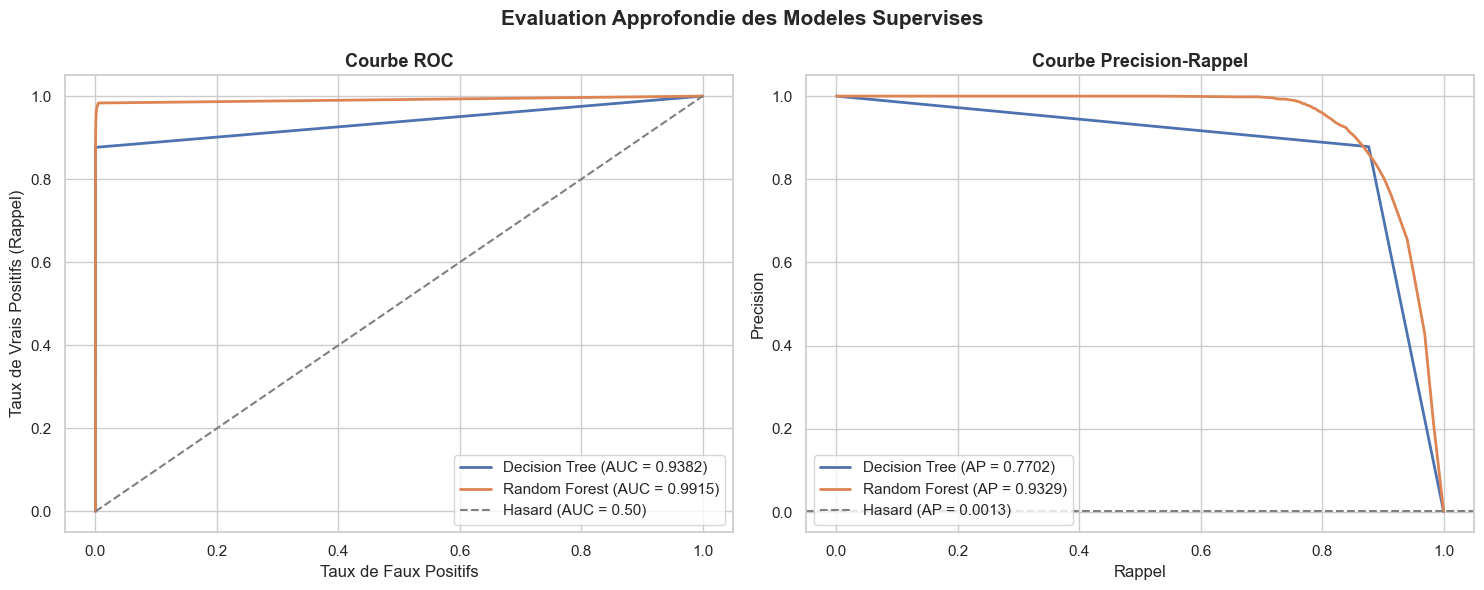

--- Scores resumes ---
Decision Tree        | AUC-ROC = 0.9382 | Average Precision = 0.7702
Random Forest        | AUC-ROC = 0.9915 | Average Precision = 0.9329


In [23]:
# ==============================================================================
# COURBES ROC ET PRECISION-RAPPEL (essentielles sur donnees desequilibrees)
# ==============================================================================

# Probabilites de la classe positive (Fraude) pour chaque modele
y_proba_dt = dt_model.predict_proba(X_test_final)[:, 1]
y_proba_rf = rf_model.predict_proba(X_test_final)[:, 1]

models_proba = {
    'Decision Tree': y_proba_dt,
    'Random Forest': y_proba_rf
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Courbe ROC ---
for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})", linewidth=2)

axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey', label='Hasard (AUC = 0.50)')
axes[0].set_xlabel("Taux de Faux Positifs")
axes[0].set_ylabel("Taux de Vrais Positifs (Rappel)")
axes[0].set_title("Courbe ROC", fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')

# --- Courbe Precision-Rappel (plus pertinente ici que ROC) ---
for name, proba in models_proba.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap_score = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, label=f"{name} (AP = {ap_score:.4f})", linewidth=2)

baseline_rate = y_test.mean()
axes[1].axhline(y=baseline_rate, linestyle='--', color='grey', label=f'Hasard (AP = {baseline_rate:.4f})')
axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Precision")
axes[1].set_title("Courbe Precision-Rappel", fontsize=13, fontweight='bold')
axes[1].legend(loc='lower left')

plt.suptitle("Evaluation Approfondie des Modeles Supervises", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("--- Scores resumes ---")
for name, proba in models_proba.items():
    print(f"{name:20s} | AUC-ROC = {roc_auc_score(y_test, proba):.4f} | Average Precision = {average_precision_score(y_test, proba):.4f}")

## 8. Importance des variables

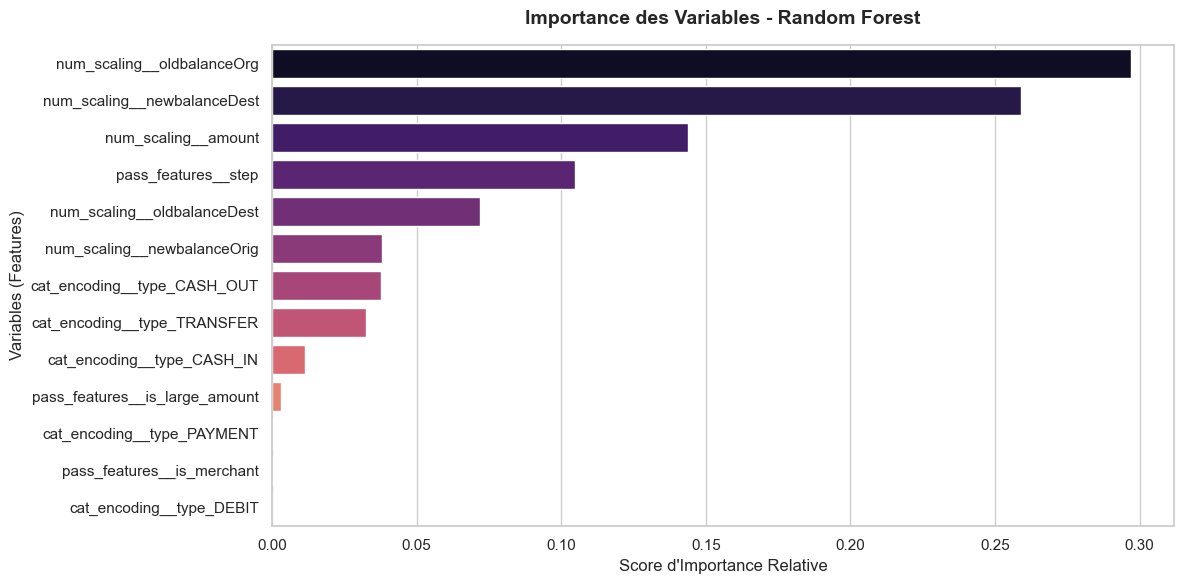

--- Top 5 des variables les plus discriminantes ---
                    Feature  Importance
 num_scaling__oldbalanceOrg    0.297057
num_scaling__newbalanceDest    0.258839
        num_scaling__amount    0.144006
        pass_features__step    0.104695
num_scaling__oldbalanceDest    0.072071


In [24]:
# ==============================================================================
# VISUALIZING FEATURE IMPORTANCE WITH BALANCE ERRORS
# ==============================================================================

# 1. Extraction de l'importance des variables calculees par le Random Forest
importances_with_error = rf_model.feature_importances_
feature_names_with_error = X_train_final.columns

# Creation du DataFrame ordonne
df_importance_with_error = pd.DataFrame({
    'Feature': feature_names_with_error,
    'Importance': importances_with_error
}).sort_values(by='Importance', ascending=False)

# 2. Creation du graphique avec Seaborn et Matplotlib
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=df_importance_with_error,
    palette='magma'
)

plt.title("Importance des Variables - Random Forest", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Score d'Importance Relative", fontsize=12)
plt.ylabel("Variables (Features)", fontsize=12)
plt.tight_layout()
plt.show()

# 3. Affichage textuel du Top 5 pour le rapport
print("--- Top 5 des variables les plus discriminantes ---")
print(df_importance_with_error.head(5).to_string(index=False))

## 9. Analyse en Composantes Principales (ACP)

Cette section répond à l'exigence de la note de cadrage (4.5 — fondements mathématiques : variance expliquée, normalisation) et à la méthodologie annoncée dans le résumé du projet intégrateur.

--- Debut de l'Analyse en Composantes Principales (ACP) ---


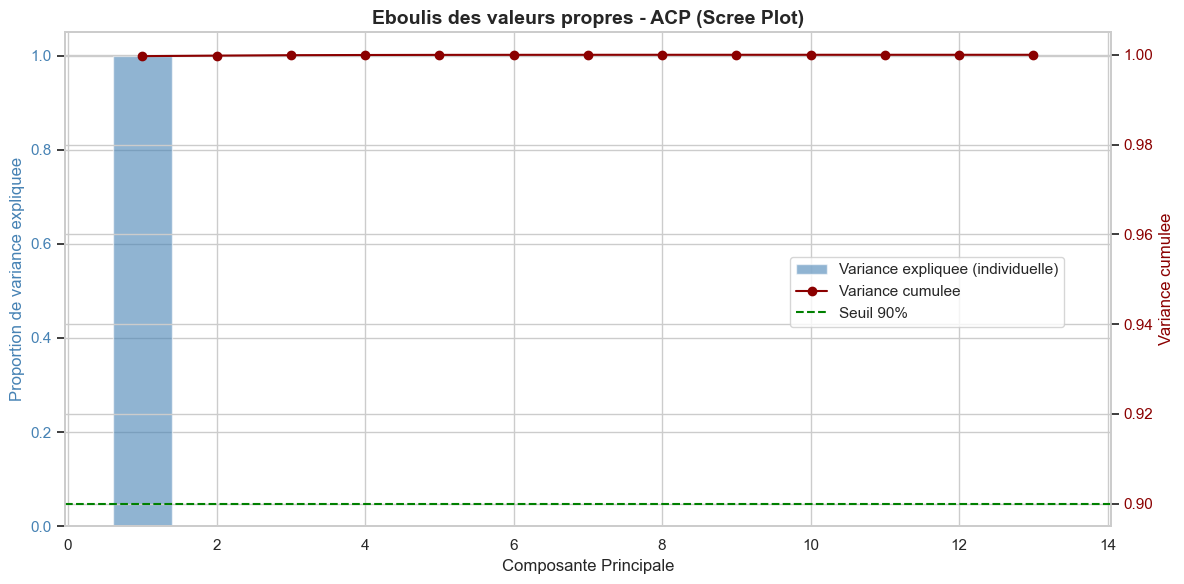

--> Nombre de composantes necessaires pour expliquer 90% de la variance : 1
--> Variance expliquee par les 2 premieres composantes : 99.98%


In [25]:
# ==============================================================================
# ANALYSE EN COMPOSANTES PRINCIPALES (ACP / PCA)
# ==============================================================================

print("--- Debut de l'Analyse en Composantes Principales (ACP) ---")

# Application de l'ACP sur les donnees pretraitees (deja standardisees par le pipeline)
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_final)

# Variance expliquee par chaque composante
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Eboulis des valeurs propres (Scree plot) + variance cumulee
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, color='steelblue', label='Variance expliquee (individuelle)')
ax1.set_xlabel("Composante Principale")
ax1.set_ylabel("Proportion de variance expliquee", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(range(1, len(explained_var)+1), cumulative_var, color='darkred', marker='o', label='Variance cumulee')
ax2.axhline(y=0.90, color='green', linestyle='--', label='Seuil 90%')
ax2.set_ylabel("Variance cumulee", color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

fig.legend(loc='center right', bbox_to_anchor=(0.9, 0.5))
plt.title("Eboulis des valeurs propres - ACP (Scree Plot)", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# Nombre de composantes necessaires pour 90% de variance
n_components_90 = int(np.argmax(cumulative_var >= 0.90) + 1)
print(f"--> Nombre de composantes necessaires pour expliquer 90% de la variance : {n_components_90}")
print(f"--> Variance expliquee par les 2 premieres composantes : {cumulative_var[1]*100:.2f}%")

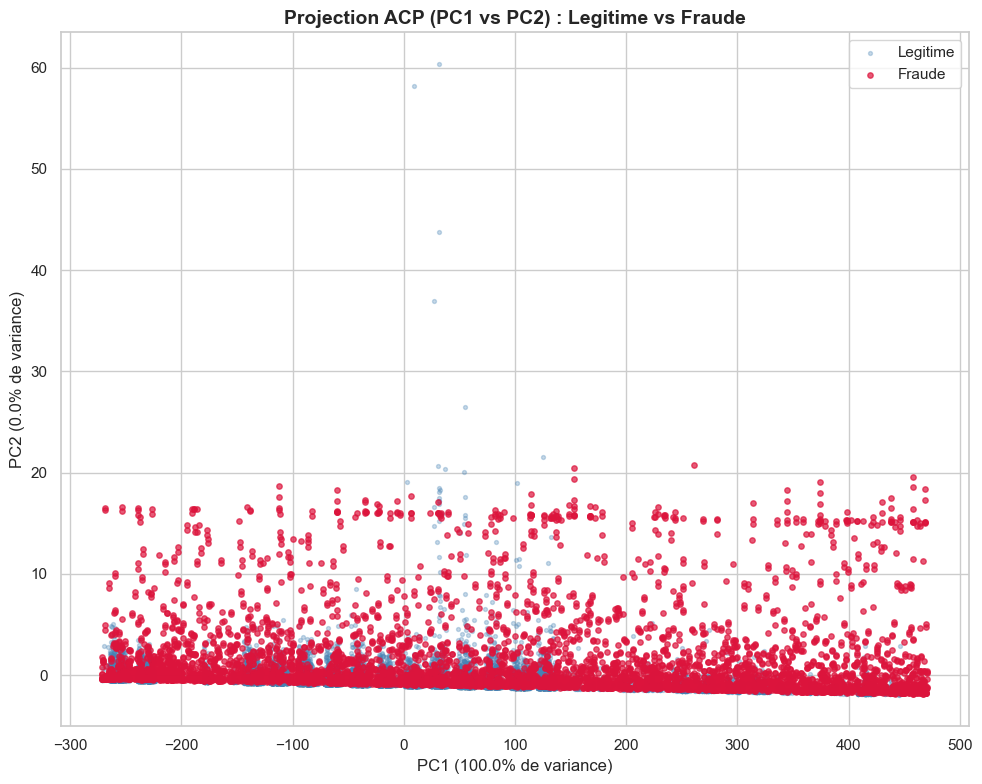

In [26]:
# ==============================================================================
# PROJECTION 2D DE L'ACP (PC1 vs PC2) COLOREE PAR STATUT DE FRAUDE
# ==============================================================================

# Reduction a 2 composantes pour la visualisation
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)

# Echantillonnage stratifie : toutes les fraudes + 20 000 legitimes
# (4.4M points rendrait le scatter illisible)
sample_size_legit = 20000
idx_fraud = y_train[y_train == 1].index
idx_legit = y_train[y_train == 0].sample(n=sample_size_legit, random_state=RANDOM_STATE).index
idx_sample = idx_fraud.union(idx_legit)

X_sample = X_train_final.loc[idx_sample]
y_sample = y_train.loc[idx_sample]

X_pca_2d = pca_2d.fit_transform(X_sample)

# Scatter plot des 2 premieres composantes
plt.figure(figsize=(10, 8))
plt.scatter(X_pca_2d[y_sample.values==0, 0], X_pca_2d[y_sample.values==0, 1],
            s=8, alpha=0.3, c='steelblue', label='Legitime')
plt.scatter(X_pca_2d[y_sample.values==1, 0], X_pca_2d[y_sample.values==1, 1],
            s=15, alpha=0.7, c='crimson', label='Fraude')
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% de variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% de variance)")
plt.title("Projection ACP (PC1 vs PC2) : Legitime vs Fraude", fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# ==============================================================================
# CERCLE DES CORRELATIONS : CONTRIBUTION DES VARIABLES AUX AXES PC1/PC2
# ==============================================================================

loadings = pca_2d.components_.T * np.sqrt(pca_2d.explained_variance_)

fig, ax = plt.subplots(figsize=(9, 9))
circle = plt.Circle((0, 0), 1, color='grey', fill=False, linestyle='--')
ax.add_artist(circle)

for i, feature in enumerate(X_train_final.columns):
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1], head_width=0.02, color='darkorange', alpha=0.8)
    ax.text(loadings[i, 0]*1.12, loadings[i, 1]*1.12, feature, fontsize=8, ha='center')

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Cercle des Correlations - Contribution des Variables", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tableau des contributions triees par poids sur PC1
df_loadings = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=X_train_final.columns)
print("--- Contribution des variables aux 2 premiers axes (triee par |PC1|) ---")
print(df_loadings.reindex(df_loadings['PC1'].abs().sort_values(ascending=False).index))

--- Contribution des variables aux 2 premiers axes (triee par |PC1|) ---
                                       PC1       PC2
pass_features__step             169.551971 -0.004797
num_scaling__amount               0.340003  2.215762
cat_encoding__type_TRANSFER       0.056061  0.099411
num_scaling__oldbalanceOrg        0.052816  0.558576
pass_features__is_large_amount    0.051233  0.197567
pass_features__is_merchant       -0.039845 -0.106930
cat_encoding__type_PAYMENT       -0.039845 -0.106930
cat_encoding__type_CASH_IN       -0.029671 -0.006565
num_scaling__newbalanceOrig      -0.023312  0.171616
num_scaling__newbalanceDest       0.021704  0.475069
cat_encoding__type_CASH_OUT       0.014158  0.015562
num_scaling__oldbalanceDest      -0.001355  0.287055
cat_encoding__type_DEBIT         -0.000703 -0.001478


## 10. Détection d'anomalies non supervisée (Isolation Forest, DBSCAN)

Le résumé du projet intégrateur annonce Isolation Forest, DBSCAN et ACP. Cette section fournit ce complément non supervisé et le compare à l'approche supervisée, en soulignant un point clé pour le rapport (section 4.7) : en production réelle, les nouveaux schémas de fraude ne sont pas toujours étiquetés — d'où l'intérêt de méthodes qui n'exigent pas de label.

In [28]:
# ==============================================================================
# DETECTION D'ANOMALIES NON SUPERVISEE : ISOLATION FOREST
# ==============================================================================

print("--- Isolation Forest : approche non supervisee complementaire ---")

# Contamination = proportion de fraude observee dans le Train set.
# En production reelle ce taux ne serait pas connu a l'avance : ici il sert
# uniquement de calibrage pedagogique puisque nous disposons des labels.
contamination_rate = y_train.mean()
print(f"Taux de contamination utilise : {contamination_rate:.6f}")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=contamination_rate,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X_train_final)

# Predictions : -1 = anomalie, 1 = normal -> conversion en 0/1 pour comparer a isFraud
y_pred_iso = iso_forest.predict(X_test_final)
y_pred_iso_binary = np.where(y_pred_iso == -1, 1, 0)

print("\n--- Evaluation de l'Isolation Forest (non supervise) vs les vraies fraudes ---")
print(classification_report(y_test, y_pred_iso_binary, target_names=['Legitime', 'Fraude']))

cm_iso = confusion_matrix(y_test, y_pred_iso_binary)
print("Matrice de confusion Isolation Forest:")
print(cm_iso)
tn_iso, fp_iso, fn_iso, tp_iso = cm_iso.ravel()
print(f"-> Fraudes detectees (Vrais Positifs) : {tp_iso:,}")
print(f"-> Fraudes ratees (Faux Negatifs)     : {fn_iso:,}")
print(f"-> Bons clients bloques (Faux Positifs) : {fp_iso:,}")

--- Isolation Forest : approche non supervisee complementaire ---
Taux de contamination utilise : 0.001291

--- Evaluation de l'Isolation Forest (non supervise) vs les vraies fraudes ---
              precision    recall  f1-score   support

    Legitime       1.00      1.00      1.00   1906322
      Fraude       0.02      0.02      0.02      2464

    accuracy                           1.00   1908786
   macro avg       0.51      0.51      0.51   1908786
weighted avg       1.00      1.00      1.00   1908786

Matrice de confusion Isolation Forest:
[[1904091    2231]
 [   2410      54]]
-> Fraudes detectees (Vrais Positifs) : 54
-> Fraudes ratees (Faux Negatifs)     : 2,410
-> Bons clients bloques (Faux Positifs) : 2,231


--- DBSCAN applique sur la projection ACP (PC1, PC2) de l'echantillon ---
Nombre de clusters detectes : 257
Nombre de points consideres comme bruit/anomalie (label -1) : 5,930 sur 25,749


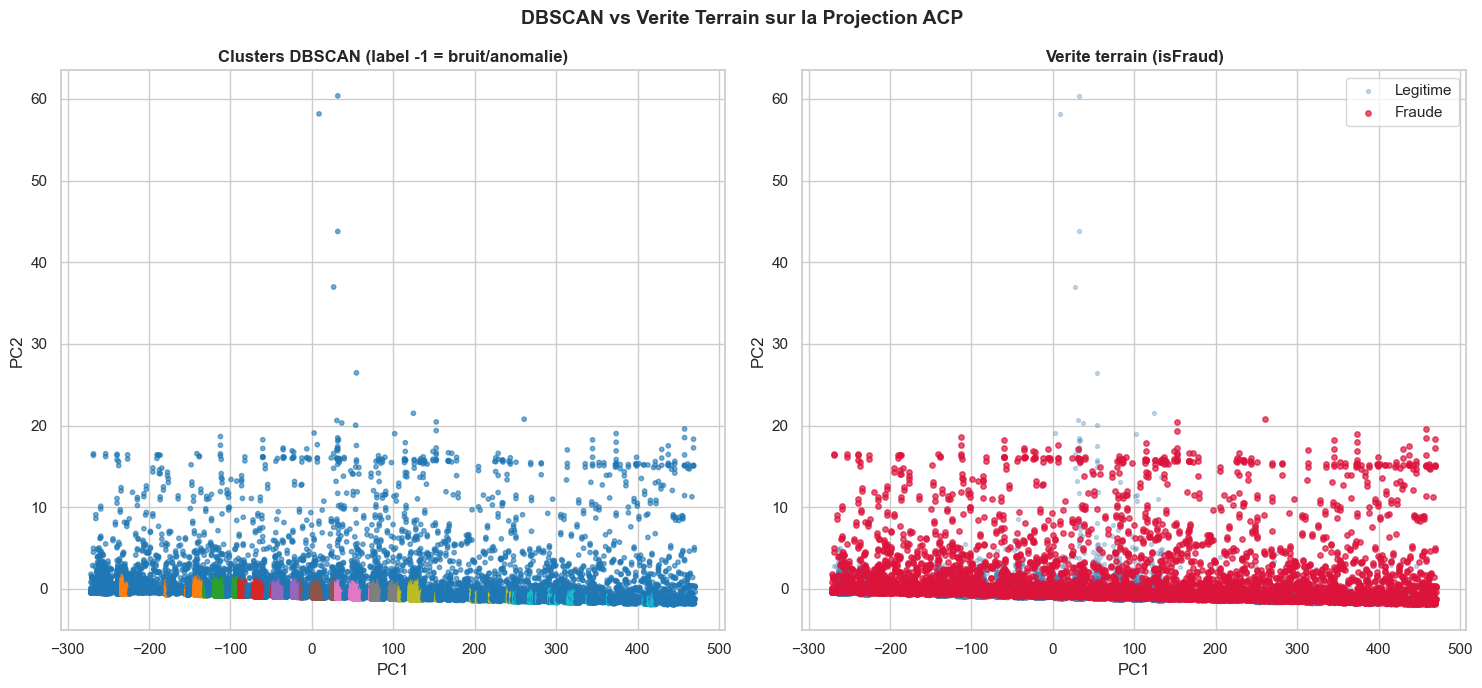


--- Le bruit detecte par DBSCAN recoupe-t-il les vraies fraudes ? ---
              precision    recall  f1-score   support

    Legitime       0.93      0.92      0.93     20000
      Fraude       0.74      0.77      0.75      5749

    accuracy                           0.89     25749
   macro avg       0.84      0.84      0.84     25749
weighted avg       0.89      0.89      0.89     25749

Note : DBSCAN n'est pas concu pour la classification binaire ; il sert ici a
valider visuellement la separabilite des fraudes dans l'espace reduit par l'ACP.


In [29]:
# ==============================================================================
# DETECTION D'ANOMALIES NON SUPERVISEE : DBSCAN (sur l'espace reduit par ACP)
# ==============================================================================
# DBSCAN est un algorithme base sur la densite, non scalable a 4.4M lignes.
# On l'applique donc sur l'echantillon deja utilise pour l'ACP, projete en 2D,
# ce qui permet en plus une lecture visuelle directe des clusters/anomalies.

print("--- DBSCAN applique sur la projection ACP (PC1, PC2) de l'echantillon ---")

dbscan_model = DBSCAN(eps=0.6, min_samples=15, n_jobs=-1)
dbscan_labels = dbscan_model.fit_predict(X_pca_2d)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int((dbscan_labels == -1).sum())
print(f"Nombre de clusters detectes : {n_clusters}")
print(f"Nombre de points consideres comme bruit/anomalie (label -1) : {n_noise:,} sur {len(dbscan_labels):,}")

# Visualisation : clusters DBSCAN vs vraies fraudes, cote a cote
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=dbscan_labels, cmap='tab10', s=10, alpha=0.6)
axes[0].set_title("Clusters DBSCAN (label -1 = bruit/anomalie)", fontweight='bold')
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(X_pca_2d[y_sample.values==0, 0], X_pca_2d[y_sample.values==0, 1],
                s=8, alpha=0.3, c='steelblue', label='Legitime')
axes[1].scatter(X_pca_2d[y_sample.values==1, 0], X_pca_2d[y_sample.values==1, 1],
                s=15, alpha=0.7, c='crimson', label='Fraude')
axes[1].set_title("Verite terrain (isFraud)", fontweight='bold')
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend()

plt.suptitle("DBSCAN vs Verite Terrain sur la Projection ACP", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Croisement : le bruit DBSCAN correspond-il aux fraudes reelles ?
dbscan_noise_binary = (dbscan_labels == -1).astype(int)
print("\n--- Le bruit detecte par DBSCAN recoupe-t-il les vraies fraudes ? ---")
print(classification_report(y_sample.values, dbscan_noise_binary, target_names=['Legitime', 'Fraude'], zero_division=0))
print("Note : DBSCAN n'est pas concu pour la classification binaire ; il sert ici a")
print("valider visuellement la separabilite des fraudes dans l'espace reduit par l'ACP.")

## 11. Synthèse, limites et considérations éthiques

### Synthèse comparative des approches

| Approche | Modèle | Usage du label `isFraud` | Points forts | Points faibles |
|---|---|---|---|---|
| Supervisée | Decision Tree / Random Forest | Oui | Haute précision et rappel, exploite tout le signal disponible | Nécessite des labels fiables et à jour ; risque de sur-apprentissage sur les schémas de fraude déjà connus |
| Non supervisée | Isolation Forest | Non | Détecte des anomalies sans historique labellisé — utile face à de **nouveaux** schémas de fraude | Davantage de faux positifs ; contamination à calibrer |
| Non supervisée | DBSCAN (sur ACP) | Non | Visualisation directe de la séparabilité des fraudes dans l'espace réduit | Sensible aux hyperparamètres (eps, min_samples) ; peu scalable |
| Réduction de dimension | ACP | Non | Réduit la redondance des variables de solde, facilite la visualisation | Perte d'interprétabilité directe des composantes |

### Pourquoi le pivot de la méthodologie annoncée en avril 2026 ?
Le résumé initial prévoyait une approche exclusivement non supervisée sur données synthétiques, faute d'accès à des données réelles labellisées. L'utilisation du jeu de données public **PaySim**, qui reproduit fidèlement la structure des transactions mobile money (montants, types TRANSFER/CASH_OUT, comptes marchands) et fournit un label `isFraud` fiable, a permis d'aller plus loin : comparer une approche supervisée robuste à l'approche non supervisée initialement prévue, tout en conservant ACP, Isolation Forest et DBSCAN comme prévu dans les mots-clés du sujet.

### Limites identifiées
- **Déséquilibre extrême des classes** (~0.13% de fraude) : l'accuracy seule est trompeuse ; les métriques de précision/rappel/AUC-PR ont été privilégiées.
- **Données synthétiques (PaySim)** : bien que réalistes, elles ne reproduisent pas les spécificités locales exactes de MonCash/NatCash (agents, zones géographiques, comportements haïtiens).
- **Fuite de données potentielle** : les variables `errorBalanceOrig`/`errorBalanceDest` sont très corrélées à la fraude par construction du simulateur ; leur poids doit être interprété avec prudence en conditions réelles.
- **DBSCAN et Isolation Forest** sont appliqués sur un échantillon ou une projection réduite pour des raisons de scalabilité, ce qui limite la généralisation directe à l'ensemble des 4,4 millions de transactions.

### Considérations éthiques et pratiques
- **Confidentialité** : en conditions réelles, les identifiants de comptes et montants sont des données sensibles ; leur usage devrait suivre les règles de protection des données et de conformité BRH.
- **Biais potentiels** : un modèle entraîné sur des schémas de fraude passés peut sous-détecter des fraudes émergentes ou sur-cibler certains types de transactions/canaux, avec un risque de blocage injustifié de bons clients (faux positifs).
- **Usage responsable** : un score de risque doit rester une **aide à la décision** pour les équipes conformité, non une décision automatique de blocage, afin de préserver l'accès aux services financiers pour les usagers légitimes.